# redistribution
#### Hubeny & Mihales 2004,  Ch.10
#### frequency redistribution in observer's frame

#### note in \home\doc\work\NLTE\freq.redistribution.pptx

In [1]:
import numpy as np

#%matplotlib inline
#%matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%load_ext autoreload
%autoreload 2
import sys

from spectra.ImportAll import *
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)



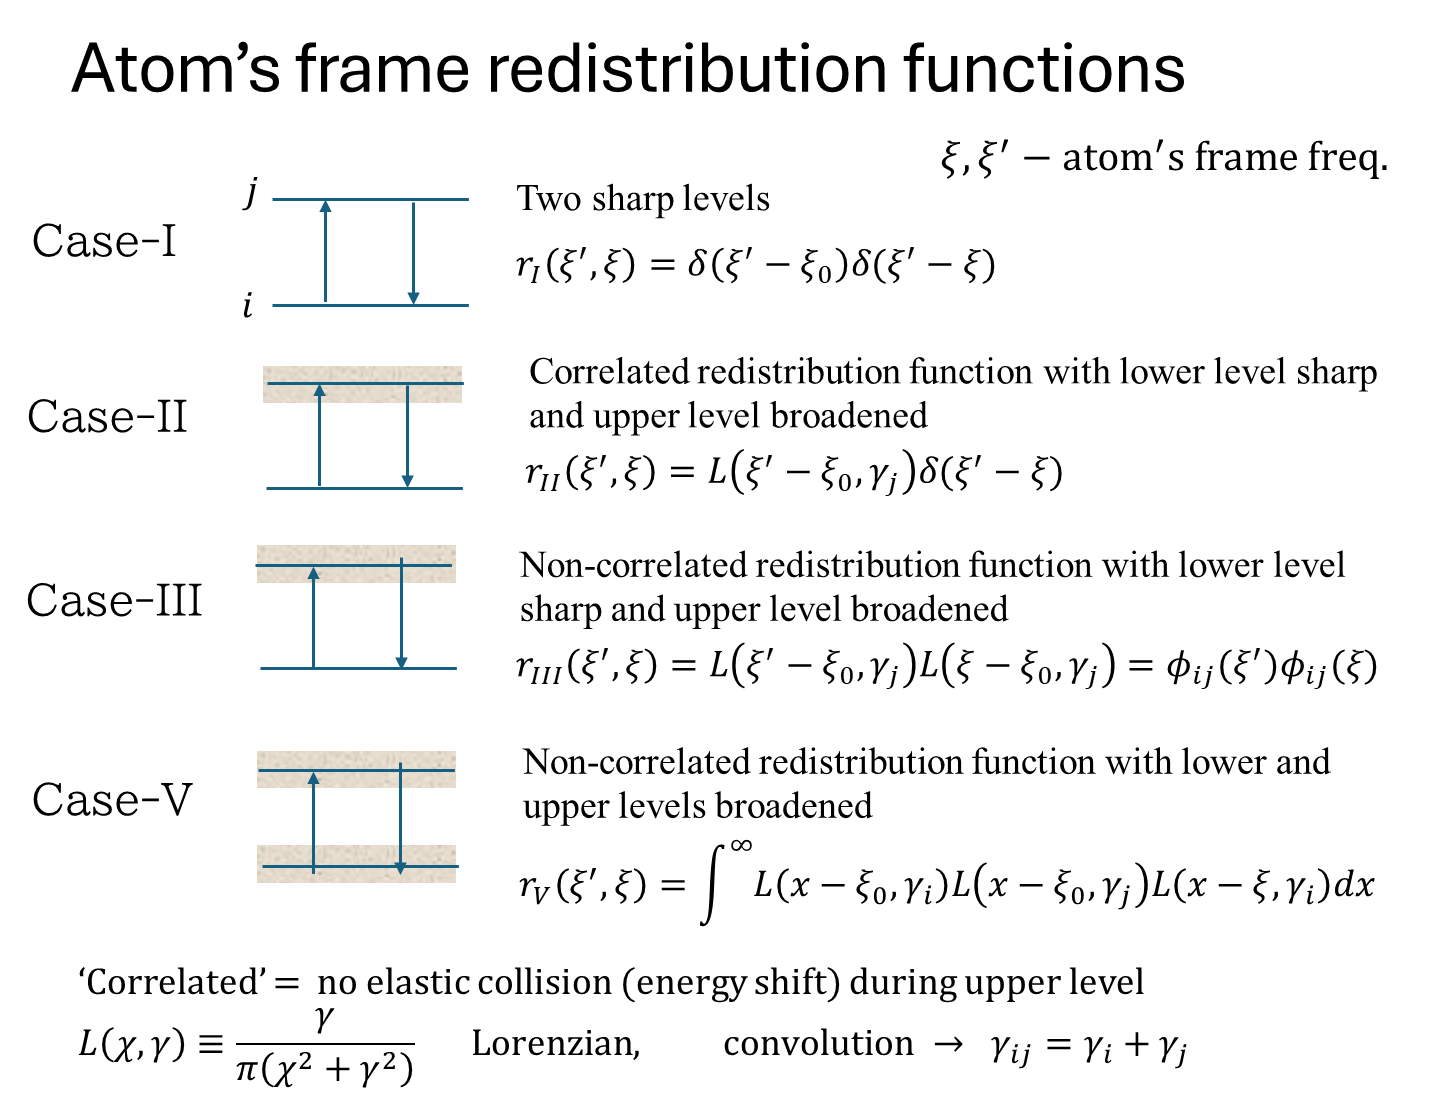

# Observer's frame redistribution function

$x',  x $ -- incident and scattered freq. (or wavelength) from line center in unit of Doppler width

##### $R_I(𝑥',𝐧';𝑥,𝐧)=\frac{g(𝐧',𝐧)}{\pi \sin\Theta} \exp [-x^2 -\frac{(x'-x \cos\Theta)^2}{\sin^2\Theta}]$

##### $R_{II}(𝑥',𝐧';𝑥,𝐧)=\frac{g(𝐧',𝐧)}{\pi \sin\Theta} \exp [-\frac{1}{4}\frac{(x'-x)^2}{\sin^2\Theta}] H(\frac{a}{\cos (\Theta/2)},\frac{1}{2}\frac{x+x'}{\cos (\Theta/2)})$

$\qquad   H$ - Voigt function,   $a$ - damping $\gamma$ in unit of Dopp. width




In [ ]:
## sympy experiment
from sympy import *
import sympy
from IPython.display import Math
#init_printing()

x0, x1, th = symbols('x_in x_out Theta', real=True)

R1 = 1/pi/sin(th) *exp(-x1**2-(x0-x1*cos(th))**2/sin(th)**2)
display(R1)
#limit(R1, th,0)
#limit(exp(-x0**2/sin(th)**2)/sin(th), th,0)

exp(-x_out**2 - (x_in - x_out*cos(Theta))**2/sin(Theta)**2)/(pi*sin(Theta))

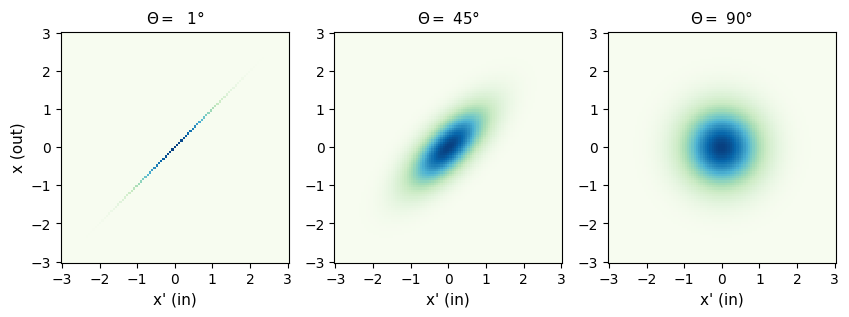

In [159]:
from spectra.Experimental import ExLine as _Line
from spectra.RadiativeTransfer import Profile as _Profile   # hf_(a,x)

n = 101 ; xmax = 3
x = np.linspace(-xmax,xmax,nn)   # 
x0,x1 = np.meshgrid(x,x)
a = 1.5e-4

th = 90

case = 'II'
fig, axs = plt.subplots(1,3, figsize=(10,3), dpi=100)

count = 0
for th in [1,45,90]:
    thr = th*np.pi/180.
    if case == 'I':  
        Rmat = 1/np.pi/np.sin(thr) *np.exp(-x1**2-(x0-x1*np.cos(thr))**2/np.sin(thr)**2) 
    elif case == 'II':
        h, f = _Profile.hf_(a/np.cos(thr/2), 1./2.*(x1+x0)/np.cos(thr/2))
        Rmat = 1/np.pi/np.sin(thr) *np.exp(-1./4.*((x1-x0)**2)/np.sin(thr/2)**2) *h

    ax = axs[count]
    ax.pcolormesh(x0,x1,Rmat, cmap='GnBu')    # 'Blues
    #ax.imshow( Rmat, origin="lower", cmap='cool', aspect='equal' )
    ax.set_title(f"$\Theta=${th:3d}$\degree$", fontsize=11)
    ax.set_xlabel("x' (in)", fontsize=11)
    if count == 0:
        ax.set_ylabel("x (out)", fontsize=11)
    ax.set_xticks(np.arange(-xmax,xmax+1,dtype='int'))
    ax.set_yticks(np.arange(-xmax,xmax+1,dtype='int'))
    count += 1

plt.show()


In [158]:
# HeI 1083nm   HeI 1s2p 3P0,1,2      
A = 1.0216e+07  # s-1,    NIST ASD Output: Lines
w0 = 1083.0     # nm
ma = 6.65e-24   # g
c_ = 3.e10      # cm/s
k_ = 1.38e-16   
T = 8000.       # K


# Natural damping width
# ℎΔ𝜈Δ𝑡~ℏ/2     →    Δ𝜈~𝐴/4𝜋
dw_N = (w0*1e-7)**2/c_*A/4/np.pi *1e7*1e4  # mA
# Thermal width
dw_D = w0/c_*np.sqrt(2*k_*T/ma)*1e4     # mA

print(dw_N, dw_D, dw_N/dw_D)


0.03178386290339153 208.01560381031857 0.00015279557072254068


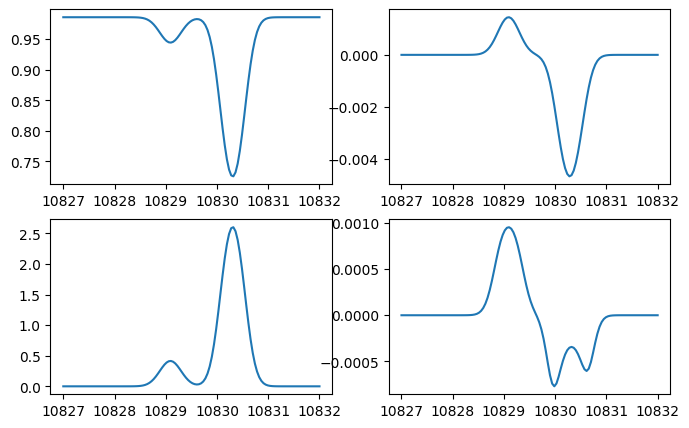

In [184]:
# sample profile from 'Hazel_synthesis.ipynb'

#d = np.load('C:\home\Python\spectra\test\tmp\hazelprof.npz')
d = np.load('hazelprof.npz')  # theta=20deg., height=32", Bx=10, By=0, Bz=0, vturb=8km/s, tau=0.5, 
wl = d['arr_0']
s = d['arr_1']
I = s[0,:] ;  Q = s[1,:] ;  U = s[2,:] ;  V = s[3,:]

fig, axs = plt.subplots(2,2, figsize=(8,5), dpi=100)
axs = axs.flatten()

tau = (s[0,0]-s[0,:])*10

axs[0].plot(wl,I)
axs[1].plot(wl,Q)
axs[2].plot(wl,tau)
axs[3].plot(wl,Q*np.exp(-tau))
